In [1]:
import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F 

import matplotlib.pyplot as plt 
import seaborn as sns

## Generate example data

((100,), (100,))

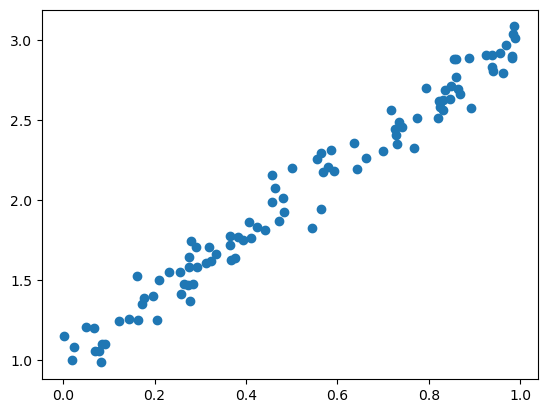

In [2]:
np.random.seed(1999)
torch.manual_seed(1999)

M = 2
B = 1
SIGMA = 0.1

x = np.random.uniform(low=0, high=1, size=100)
x = np.sort(x)
y = M * x + B + np.random.normal(loc=0, scale=SIGMA, size=100)

plt.scatter(x, y)

x.shape, y.shape

In [3]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, x, y):
        x = x.copy().reshape(-1,1)
        y = y.copy().reshape(-1,1)
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx, :]

train_dataset = CustomDataset(x, y)
test_dataset = CustomDataset(x, y)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

## Code for the Linear Model

In [4]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.rand(1, dtype=torch.float32))
        self.b = nn.Parameter(torch.zeros(1, dtype=torch.float32))
    
    def forward(self, x):
        y_pred = self.w * x + self.b
        return y_pred

    def return_mean_gradients(self):
        return (np.mean(np.abs(self.w.grad.detach().numpy())) + np.mean(np.abs(self.b.grad.detach().numpy()))) / 2

## Code for the MLP Model

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden_size=10):
        super().__init__()
        self.hidden = nn.Linear(1, hidden_size)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = F.relu(x)
        x = self.head(x)
        return x

    def return_mean_gradients(self):
        gradient, count = 0.0, 0.0
        for weight in [self.hidden.weight, self.hidden.bias, self.head.weight, self.head.bias]:
            gradient += np.mean(np.abs(weight.grad.detach().numpy()))
            count += weight.grad.shape[0]
        return gradient / count

## Training and Evaluation Loops

In [6]:
LR = 0.1
EPOCHS = 150

def train_step(model, data_loader, loss_fn, optimizer):
    # put the model in training mode
    model.train()
    # init the train loss
    train_loss = 0.0
    # create the grad tracking container
    gradients = 0
    # iterate over the examples
    for inputs, labels in data_loader:
        # Zero the gradients
        optimizer.zero_grad()
        # get the predictions
        preds = model(inputs)
        # get the loss
        loss = loss_fn(preds, labels)
        # update the gradients with respects to the loss
        loss.backward()
        # update the weights
        optimizer.step()
        # add the epoch loss
        train_loss += loss.item()
        # see if we are tracking the grads
        gradients += model.return_mean_gradients()
    # return the average loss which is good to know
    return train_loss / len(data_loader), gradients / len(data_loader)

def test_step(model, data_loader, loss_fn):
    # set the model to eval
    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        for inputs, labels in data_loader:
            # get the predictions
            preds = model(inputs)
            # get the loss
            loss = loss_fn(preds, labels)
            # add the epoch loss
            test_loss += loss.item()
    # return the average loss which is good to know
    return test_loss / len(data_loader)

def pred_step(model, data_loader):
    # setup the preds array
    locations = []
    predictions = []
    actuals = []
    # set the model to eval
    model.eval()
    with torch.no_grad():
        for inputs, labels in data_loader:
            # get the predictions
            preds = model(inputs)
            # add the info to the saved arrays
            locations.append(inputs.detach().numpy())
            predictions.append(preds.detach().numpy())
            actuals.append(labels.detach().numpy())
    # return the average loss which is good to know
    locations = np.concatenate(locations).flatten()
    predictions = np.concatenate(predictions).flatten()
    actuals = np.concatenate(actuals).flatten()
    return locations, predictions, actuals

def fit_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=EPOCHS, verbose=True):
    gradients = []
    for epoch in range(EPOCHS):
        # train the model
        train_loss, grads = train_step(model, train_loader, loss_fn, optimizer)
        gradients.append(grads)
        # test the model
        test_loss = test_step(model, test_loader, loss_fn)
        # print the results
        if(verbose and epoch % 100 == 0):
            print(f"Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
    # test the model
    locations, predictions, actuals = pred_step(model, test_loader)
    return locations, predictions, actuals, np.mean(gradients)

def setup_model(model_class=LinearModel, loss_fn=nn.MSELoss, lr=LR):
    model = model_class()
    loss_fn = loss_fn()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0, dampening=0, weight_decay=0, nesterov=False)
    return model, loss_fn, optimizer

def run_experiment(train_loader, test_loader, model_class=LinearModel, loss_fn=nn.MSELoss, lr=LR, verbose=True):
    model, loss_fn, optimizer = setup_model(model_class=model_class, loss_fn=loss_fn, lr=lr)
    locations, preds, actuals, gradients = fit_model(model, train_loader, test_loader, loss_fn, optimizer, verbose=verbose)
    final_loss = test_step(model, test_loader, loss_fn)
    return final_loss, locations, preds, actuals, gradients

## 1) SGD MSE Loss Line Regression

Epoch 1, Train Loss: 4.3357, Test Loss: 2.4293
Epoch 101, Train Loss: 0.0159, Test Loss: 0.0158


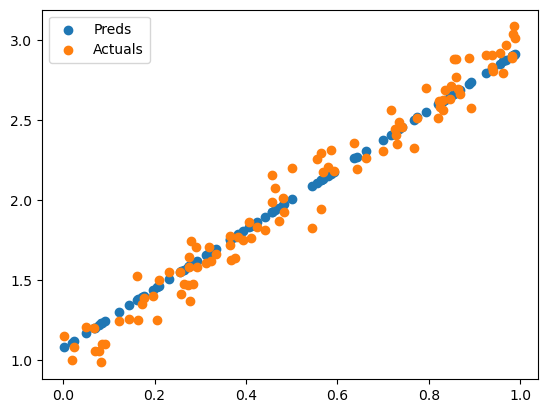

In [7]:

final_loss, locations, preds, actuals, gradients = run_experiment(train_loader, test_loader)
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")
# locations, preds, actuals

## 2) Learning Rate Experimentation

We can see that when the learning rate is around 0.7 the gradients start to explode on the line regression. Past this point the gradients begin increasing, but further on they completely explode.

In [8]:
learning_rates = np.linspace(start=0, stop=1, num=22)[1:-1]
learning_rates

array([0.04761905, 0.0952381 , 0.14285714, 0.19047619, 0.23809524,
       0.28571429, 0.33333333, 0.38095238, 0.42857143, 0.47619048,
       0.52380952, 0.57142857, 0.61904762, 0.66666667, 0.71428571,
       0.76190476, 0.80952381, 0.85714286, 0.9047619 , 0.95238095])

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:03<00:00,  6.00it/s]


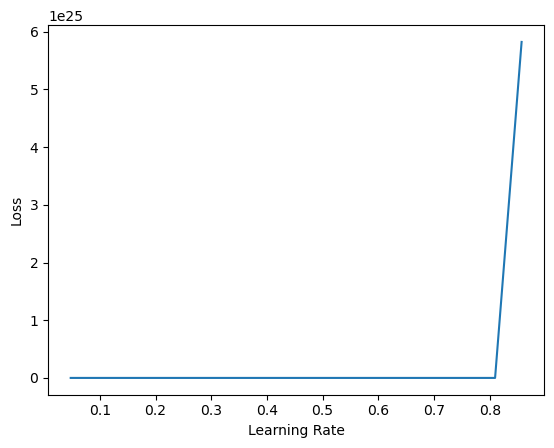

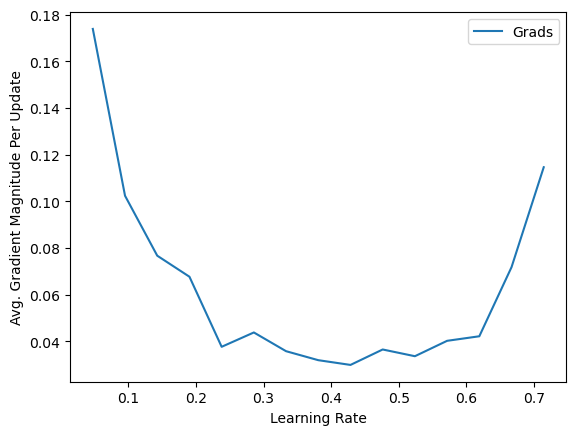

In [9]:
from tqdm import tqdm

losses = []
gradients = []
for learning_rate in tqdm(learning_rates):
    final_loss, locations, preds, actuals, grads = run_experiment(train_loader, test_loader, lr=learning_rate, verbose=False)
    losses.append(final_loss)
    gradients.append(grads)

plt.plot(learning_rates, losses)
plt.ylabel('Loss')
plt.xlabel('Learning Rate')
plt.show()
plt.plot(learning_rates[:-5], gradients[:-5], label="Grads")
plt.ylabel('Avg. Gradient Magnitude Per Update')
plt.xlabel('Learning Rate')
plt.legend()
plt.show()

In [10]:
import pandas as pd
table = pd.DataFrame()
table['Learning Rate'] = learning_rates
table['Mean Gradient Per Update'] = gradients
table

,Learning Rate,Mean Gradient Per Update
0,0.047619,1.738594e-01
1,0.095238,1.023649e-01
2,0.142857,7.667883e-02
3,0.190476,6.766325e-02
4,0.238095,3.763360e-02
5,0.285714,4.377960e-02
6,0.333333,3.575077e-02
7,0.380952,3.189984e-02
8,0.428571,2.986853e-02
9,0.476190,3.648312e-02


## 3) & 4) Regression with a MLP Model and Visualization of the Model

Epoch 1, Train Loss: 4.9614, Test Loss: 0.6941
Epoch 101, Train Loss: 0.0100, Test Loss: 0.0100


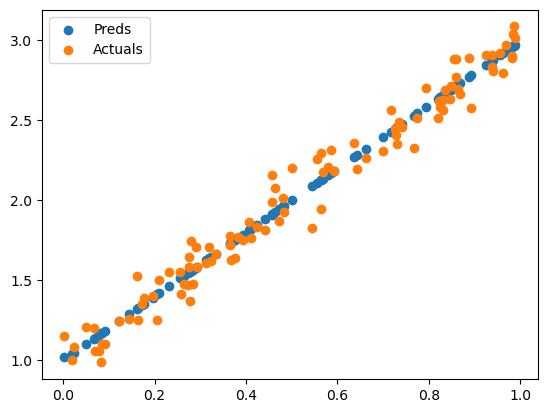

In [11]:
final_loss, locations, preds, actuals, gradients = run_experiment(train_loader, test_loader, model_class=MLP)
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")

## 5) Add Outlier to Data & Train Both MLP & Linear Model With MAE & MSE Losses

We can see that as we expect the MAE is less responsive to the outlier because the loss encoutered by this point only scales linearly rather than exponentially as the outlier gets further and further away form the target line.

The MLP Models can adapt a bit better since they don't learn a line so just the location around this point can drop down more.

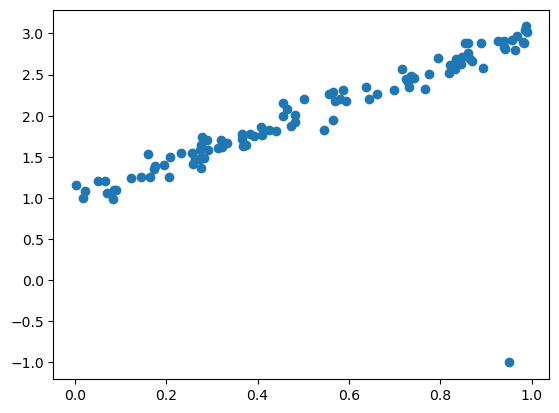

In [12]:
outlier = (0.95, -1.0)
x_outlier = np.append(x, outlier[0])
y_outlier = np.append(y, outlier[1])

train_dataset_outlier = CustomDataset(x_outlier, y_outlier)
test_dataset_outlier = CustomDataset(x_outlier, y_outlier)
train_loader_outlier = DataLoader(train_dataset_outlier, batch_size=100, shuffle=True)
test_loader_outlier = DataLoader(test_dataset_outlier, batch_size=100, shuffle=False)

plt.scatter(x_outlier, y_outlier)

Epoch 1, Train Loss: 0.2052, Test Loss: 0.7807
Epoch 101, Train Loss: 0.1979, Test Loss: 0.7419


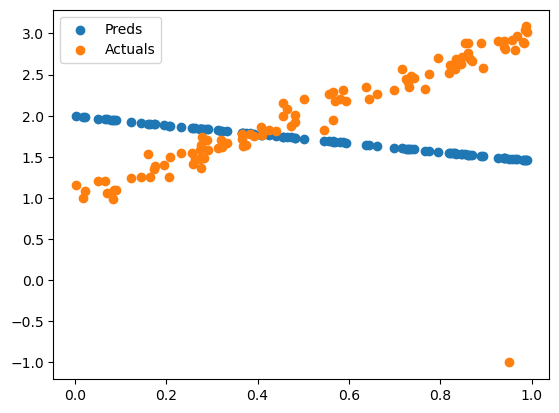

In [13]:
final_loss, locations, preds, actuals, gradients = run_experiment(train_dataset_outlier, test_dataset_outlier, model_class=LinearModel, loss_fn=nn.MSELoss)
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")

Epoch 1, Train Loss: 0.2117, Test Loss: 0.3833
Epoch 101, Train Loss: 0.1595, Test Loss: 0.1855


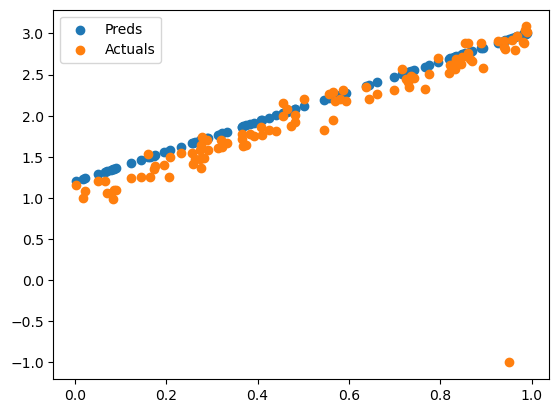

In [14]:
final_loss, locations, preds, actuals, gradients = run_experiment(train_dataset_outlier, test_dataset_outlier, model_class=LinearModel, loss_fn=nn.L1Loss)
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")

Epoch 1, Train Loss: 0.1920, Test Loss: 3.2131
Epoch 101, Train Loss: 0.1712, Test Loss: 0.2297


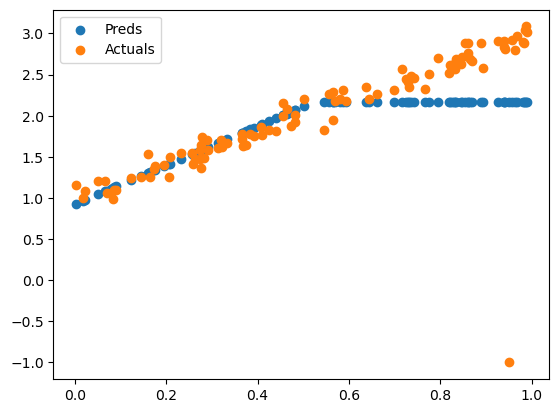

In [15]:
final_loss, locations, preds, actuals, gradients = run_experiment(train_dataset_outlier, test_dataset_outlier, model_class=MLP, loss_fn=nn.MSELoss)
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")

Epoch 1, Train Loss: 0.2842, Test Loss: 0.6239
Epoch 101, Train Loss: 0.2068, Test Loss: 0.1896


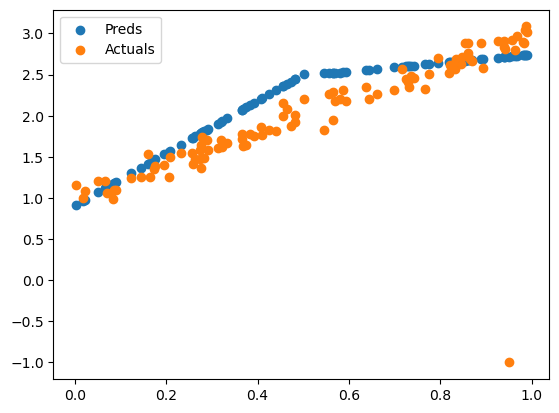

In [16]:
final_loss, locations, preds, actuals, gradients = run_experiment(train_dataset_outlier, test_dataset_outlier, model_class=MLP, loss_fn=nn.L1Loss)
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")

## 6) Results vs Outlier Point

Here we train a regression line and an MLP model to fit data that has an increasingly large outlier point. The plot below shows the non-outlier MAE as a function of the scale of the outlier. The scale was determined by multiplying the standard deviation of the random data by a multiplier to get N standard deviations away from the expectation.

We see the same conclusions here that MAE is more outlier resiliant and with just one outlier MLP models can respond better by adapting to this location. One difference is that the MAE model for the MLP doesn't seem to work out so well at fitting in this case, this could just be underfitting and resolved by adding in early stopping or lr reducing to get the final fit, but that can be left for another time.

  0%|          | 0/5 [00:00<?, ?it/s]

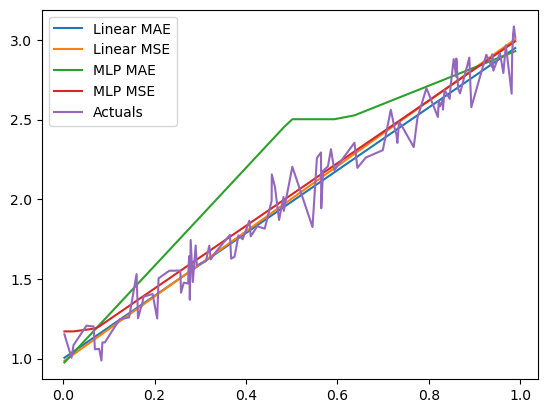

 20%|██        | 1/5 [00:11<00:44, 11.22s/it]

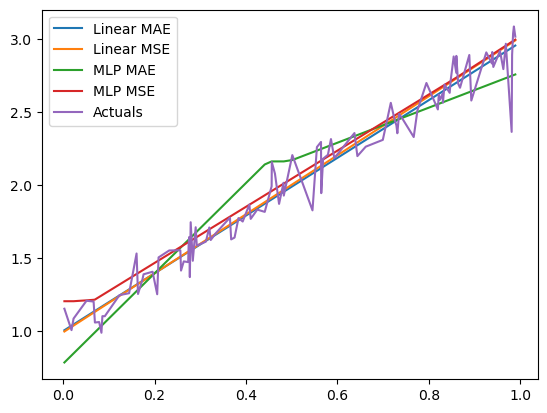

 40%|████      | 2/5 [00:22<00:33, 11.27s/it]

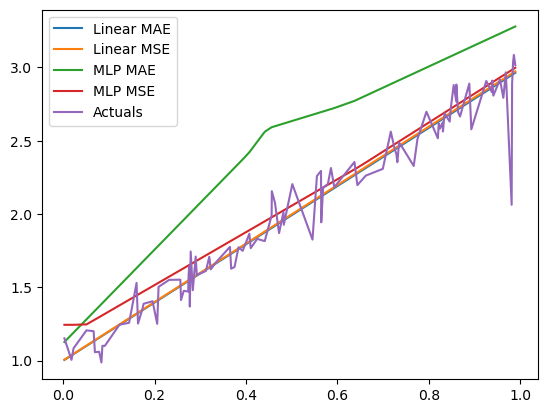

 60%|██████    | 3/5 [00:33<00:22, 11.24s/it]

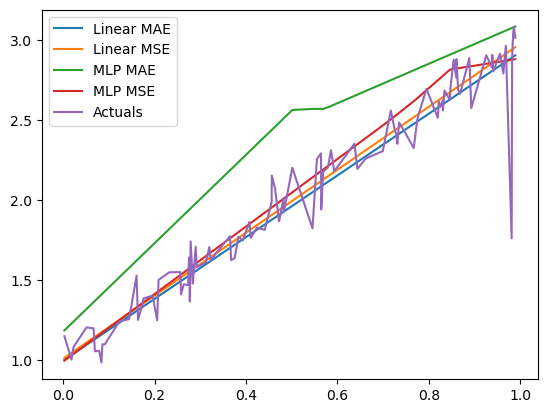

 80%|████████  | 4/5 [00:45<00:11, 11.29s/it]

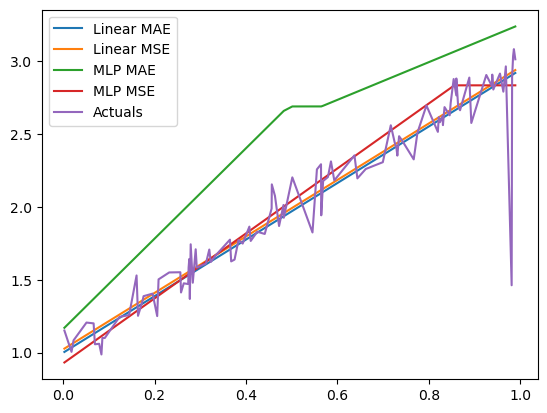

100%|██████████| 5/5 [00:56<00:00, 11.25s/it]


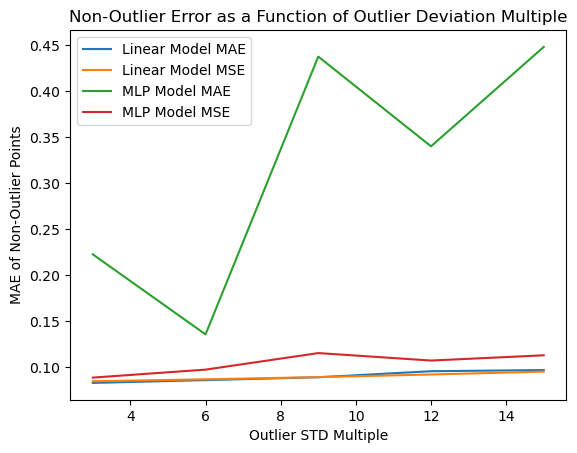

In [17]:
def get_non_outlier_mae(train_dataset_outlier, test_dataset_outlier, model_class, loss_fn, x_outlier, name=""):
    # get the results
    final_loss, locations, preds, actuals, gradients = run_experiment(train_dataset_outlier, test_dataset_outlier, model_class=model_class, loss_fn=loss_fn, verbose=False)
    # plot the stuff here
    plt.plot(x_outlier, preds, label=name)
    # remove the outlier predictions
    preds = preds[:-1]
    actuals = actuals[:-1]
    # get the mae
    return np.mean(np.abs(actuals - preds))

# get the ideal outlier point
outlier_x_idx = len(x) - 5
outlier_x = x[outlier_x_idx] 
outlier_ideal_target = M * outlier_x + B

# based on the variance get the outlier point at a number of different standard deviations from expected
# I will start at 3 since this tends to be the outlier detection range in interquantile outlier sythesis
multipliers = []
linear_mae_error = []
linear_mse_error = []
mlp_mae_error = []
mlp_mse_error = []
for std_multiplier in tqdm(range(3, 16, 3)):
    # calculate the outlier point and create the outlier dataset
    outlier_y = outlier_ideal_target - (SIGMA * std_multiplier)
    x_outlier = x.copy()
    y_outlier = y.copy()
    y_outlier[outlier_x_idx] = outlier_y
    # get the datasets
    train_dataset_outlier = CustomDataset(x_outlier, y_outlier)
    test_dataset_outlier = CustomDataset(x_outlier, y_outlier)
    train_loader_outlier = DataLoader(train_dataset_outlier, batch_size=100, shuffle=True)
    test_loader_outlier = DataLoader(test_dataset_outlier, batch_size=100, shuffle=False)
    # fit linear and mlp models with mse and mae
    multipliers.append(std_multiplier)
    linear_mae_error.append(get_non_outlier_mae(train_dataset_outlier, test_dataset_outlier, LinearModel, nn.L1Loss, x_outlier, name="Linear MAE"))
    linear_mse_error.append(get_non_outlier_mae(train_dataset_outlier, test_dataset_outlier, LinearModel, nn.MSELoss, x_outlier, name="Linear MSE"))
    mlp_mae_error.append(get_non_outlier_mae(train_dataset_outlier, test_dataset_outlier, MLP, nn.L1Loss, x_outlier, name="MLP MAE"))
    mlp_mse_error.append(get_non_outlier_mae(train_dataset_outlier, test_dataset_outlier, MLP, nn.MSELoss, x_outlier, name="MLP MSE"))
    # plot the stuff
    plt.plot(x_outlier, y_outlier, label="Actuals")
    plt.legend(loc="best")
    plt.show()
    
plt.plot(multipliers, linear_mae_error, label="Linear Model MAE")
plt.plot(multipliers, linear_mse_error, label="Linear Model MSE")
plt.plot(multipliers, mlp_mae_error, label="MLP Model MAE")
plt.plot(multipliers, mlp_mse_error, label="MLP Model MSE")
plt.legend(loc="best")
plt.ylabel('MAE of Non-Outlier Points')
plt.xlabel('Outlier STD Multiple')
plt.title('Non-Outlier Error as a Function of Outlier Deviation Multiple')
plt.show()